In [1]:
import os

from IPython import display
import tensorflow as tf
import tensorflow_io as tfio
import tensorflow_hub as hub

import numpy as np
import pandas as pd



In [2]:
yamnet_model_handle = "basemodel"
yamnet_model = hub.load(yamnet_model_handle)

In [ ]:
classes_to_include = ['Outside,urbanormanmade','Outside,ruralornatural', 'Waterfall', 'Cricket', 'Television',
                      'Environmentalnoise', 'Trafficnoise,roadwaynoise', 'Vehicle', 'Speech', 'Water', 'Wind',
                       'Rain', 'Thunderstorm', 'Train','Raindrop']
len(classes_to_include)

15

In [3]:
# csv_path = 'multiclass_labels.csv'
csv_path = 'multiclass_labels.csv'

base_path_path='./'

In [4]:
pd_data = pd.read_csv(csv_path)
pd_data.head()

,filepath,fold,breathing,chirping_birds,church_bells,clapping,clock_alarm,clock_tick,crackling_fire,crickets,...,siren,sneezing,speech,thunderstorm,toilet_flush,train,vacuum_cleaner,washing_machine,water_drops,wind
0,organized_audio2/clapping/1-115921-A-22.wav,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,organized_audio2/sneezing/2-130979-A-21.wav,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,organized_audio2/toilet_flush/4-126532-A-18.wav,2,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,organized_audio2/insects/4-143118-A-7.wav,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,organized_audio2/rain/5-194892-A-10.wav,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Utility functions for loading audio files and making sure the sample rate is correct.

@tf.function
def load_wav_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
          file_contents,
          desired_channels=1)
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

In [6]:
class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
class_names =list(pd.read_csv(class_map_path)['display_name'])

# for name in class_names[:20]:
#   print(name)
# print('...')

In [11]:
labels = []

for index, row in pd_data.iterrows():
    labels.append(list(row.iloc[-30:]))

print(labels[0])


# labels = np.array(labels)
# labels.shape


[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
print(len(labels[0]))

30


In [14]:
audio_path = pd_data['filepath'].to_list
audio_path = pd_data['filepath'].to_list()

# Add './' to the start of each path
audio_path = ['./' + path for path in audio_path]


In [15]:


filenames = pd_data['filepath'].tolist()
targets = labels
folds = pd_data['fold'].tolist()
main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(30,), dtype=tf.int32, name=None),
 TensorSpec(shape=(), dtype=tf.int32, name=None))

In [16]:

train_size = (pd_data['fold'] < 3).sum()
val_size = (pd_data['fold'] == 3).sum()
test_size = (pd_data['fold'] == 4).sum()

print(f"Train size: {train_size}")
print(f"Validation size: {val_size}")
print(f"Test size: {test_size}")

Train size: 908
Validation size: 302
Test size: 302


In [17]:
def load_wav_for_map(filename, labels, fold):
  return load_wav_16k_mono(filename), labels, fold

main_ds = main_ds.map(load_wav_for_map)
main_ds.element_spec


(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(30,), dtype=tf.int32, name=None),
 TensorSpec(shape=(), dtype=tf.int32, name=None))

In [18]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet_model(wav_data)

  num_frames = tf.shape(embeddings)[0]
   # Ensure label has shape [num_classes] -> expand to [1, num_classes]
  label = tf.expand_dims(label, axis=0)  # [1, num_classes]
  labels = tf.tile(label, [num_frames, 1])  # [num_frames, num_classes]

  folds = tf.repeat(fold, repeats=num_frames)
  return embeddings, labels, folds

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(30,), dtype=tf.int32, name=None),
 TensorSpec(shape=(), dtype=tf.int32, name=None))

In [19]:
# Cache dataset after embedding extraction
cached_ds = main_ds.cache()
cached_ds = main_ds.cache("cache.tf-data")  # Will create a cache file on disk

# Filter splits using fold
train_ds = cached_ds.filter(lambda emb, label, fold: fold < 3)
val_ds   = cached_ds.filter(lambda emb, label, fold: fold == 3)
test_ds  = cached_ds.filter(lambda emb, label, fold: fold == 4)

# Remove fold column (keep embedding and label only)
def remove_fold_column(embedding, label, fold):
    return embedding, label

# Apply to all splits
train_ds = train_ds.map(remove_fold_column, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(remove_fold_column, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(remove_fold_column, num_parallel_calls=tf.data.AUTOTUNE)


# Final batching, shuffling, and prefetching
train_ds = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)


In [20]:
train_ds.element_spec

(TensorSpec(shape=(None, 1024), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 30), dtype=tf.int32, name=None))

In [33]:
from tensorflow.keras import regularizers


my_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(1024,), kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(30, activation='sigmoid')
], name='regularized_model')
my_model.summary()




Model: "regularized_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 1024)              1049600   
                                                                 
 batch_normalization_6 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dropout_6 (Dropout)         (None, 1024)              0         
                                                                 
 dense_10 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_7 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dropout_7 (Dropout)         (None, 512)         

In [34]:
my_model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                 metrics=['accuracy'])
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=1, factor=0.1, min_lr=1e-7)

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,         
    restore_best_weights=True,
    verbose=1          
)

In [35]:
train_ds.element_spec

(TensorSpec(shape=(None, 1024), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 30), dtype=tf.int32, name=None))

In [36]:
with tf.device('/GPU:0'):  # Change to '/GPU:1', '/GPU:2', etc., if you have multiple GPUs=
    history = my_model.fit(train_ds,
                        epochs=100,
                        validation_data=val_ds,
                        callbacks=[callback,lr_scheduler],
                        verbose=1)  # Set verbose=1 for detailed output


Epoch 1/100


282/282 [==============================] - 77s 243ms/step - loss: 1.9248 - accuracy: 0.4019 - val_loss: 1.5804 - val_accuracy: 0.5726 - lr: 1.0000e-04
Epoch 2/100
282/282 [==============================] - 5s 16ms/step - loss: 1.4937 - accuracy: 0.6180 - val_loss: 1.2390 - val_accuracy: 0.6449 - lr: 1.0000e-04
Epoch 3/100
282/282 [==============================] - 5s 17ms/step - loss: 1.1556 - accuracy: 0.6752 - val_loss: 0.9375 - val_accuracy: 0.6616 - lr: 1.0000e-04
Epoch 4/100
282/282 [==============================] - 5s 17ms/step - loss: 0.8637 - accuracy: 0.7077 - val_loss: 0.7138 - val_accuracy: 0.6792 - lr: 1.0000e-04
Epoch 5/100
282/282 [==============================] - 5s 17ms/step - loss: 0.6655 - accuracy: 0.7362 - val_loss: 0.5793 - val_accuracy: 0.6895 - lr: 1.0000e-04
Epoch 6/100
282/282 [==============================] - 5s 16ms/step - loss: 0.5398 - accuracy: 0.7587 - val_loss: 0.4893 - val_accuracy: 0.6962 - lr: 1.0000e-04
Epoch 7/100
282/282 [=======================

In [37]:
loss, accuracy = my_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

94/94 [==============================] - 1s 7ms/step - loss: 0.0731 - accuracy: 0.8068
Loss:  0.07312045246362686
Accuracy:  0.8067954778671265


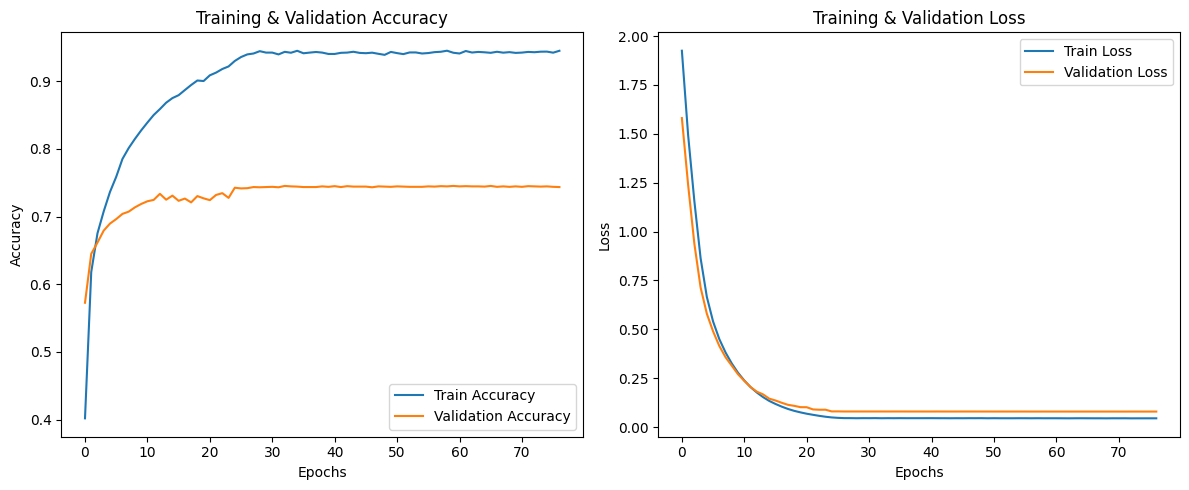

In [38]:
import matplotlib.pyplot as plt

# Extract loss and accuracy from history
history_dict = history.history

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [93]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

In [94]:
saved_model_path = './VIBRO'

input_segment = tf.keras.layers.Input(shape=(), dtype=tf.float32, name='audio')
embedding_extraction_layer = hub.KerasLayer(yamnet_model_handle,
                                            trainable=False, name='yamnet')


score, embeddings_output, _ = embedding_extraction_layer(input_segment)
serving_outputs = my_model(embeddings_output)
serving_outputs = ReduceMeanLayer(axis=0, name='classifier')(serving_outputs)
serving_model = tf.keras.Model(input_segment,     outputs={
        'yamnet_scores': score,
        'custom_classification': serving_outputs
    }
)
serving_model.save(saved_model_path, include_optimizer=False)



INFO:tensorflow:Assets written to: ./VIBRO\assets


In [95]:
reloaded_model = tf.saved_model.load(saved_model_path)

In [96]:
test_pd = pd_data.loc[pd_data['fold'] == 4]
row = test_pd.sample()
filename = row['filepath'].item()
print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')


display.Audio(waveform, rate=16000)


downloads/Outside,ruralornatural/snipped18926_start_30_end_40.wav
Waveform values: [ 6.5301776e-08 -1.9755294e-07  2.3240375e-07 ...  1.9144785e-02
  1.5378352e-02  1.9087560e-02]


In [97]:
# Run the model, check the output.
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')










my_classes = classes_to_include
reloaded_results = reloaded_model(waveform)
your_top_class = tf.argmax(reloaded_results['custom_classification'])

your_inferred_class = my_classes[your_top_class]
class_probabilities = reloaded_results['custom_classification']  # Already sigmoid outputs
print(class_probabilities)
your_top_score = class_probabilities[your_top_class]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')

yamnet_scores_from_reloaded = reloaded_results['yamnet_scores']
averaged_yamnet_scores = tf.reduce_mean(yamnet_scores_from_reloaded, axis=0)
your_top_yamnet_class_index = tf.argmax(averaged_yamnet_scores)
your_yamnet_inferred_class = class_names[your_top_yamnet_class_index]
your_yamnet_top_raw_score = averaged_yamnet_scores[your_top_yamnet_class_index].numpy() # Get the raw score
print(f'[Your model - YAMNet (Raw Score)] The main sound is: {your_yamnet_inferred_class} ({your_yamnet_top_raw_score:.4f})')


[YAMNet] The main sound is: Speech (0.3182872235774994)
tf.Tensor(
[0.02208297 0.07585916 0.10416734 0.08689125 0.00945389 0.01157978
 0.73170537 0.00387541 0.00270277 0.00574688 0.01270581 0.00273532
 0.00854292 0.00098451 0.01737212], shape=(15,), dtype=float32)
[Your model] The main sound is: Trafficnoise,roadwaynoise (0.731705367565155)
[Your model - YAMNet (Raw Score)] The main sound is: Speech (0.3183)
